# Analyse des accidents de la route — Insights clés (BAAC 2024)

## Objectif
Présenter les principaux enseignements issus de l’analyse des accidents corporels de la circulation
en France à partir des données BAAC 2024, dans une logique d’aide à la décision et de prévention.

In [1]:
import sys
from pathlib import Path

# Ajoute la racine du projet au PYTHONPATH
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Hannae\Documents\Projets\accidents-france-baac


In [2]:
import pandas as pd
from IPython.display import Image, display


DATA = Path("../data/processed")
acc = pd.read_parquet(DATA / "accidents-2024.parquet")
usag = pd.read_parquet(DATA / "usagers-2024.parquet")
pop = pd.read_parquet(DATA / "populations-2024.parquet")

print(acc.shape, usag.shape, pop.shape)

(70248, 36) (125187, 3) (96, 3)


In [3]:
from src.features import add_time_features
acc = add_time_features (acc)

## Insight 1 — Risque relatif d'accident par heure

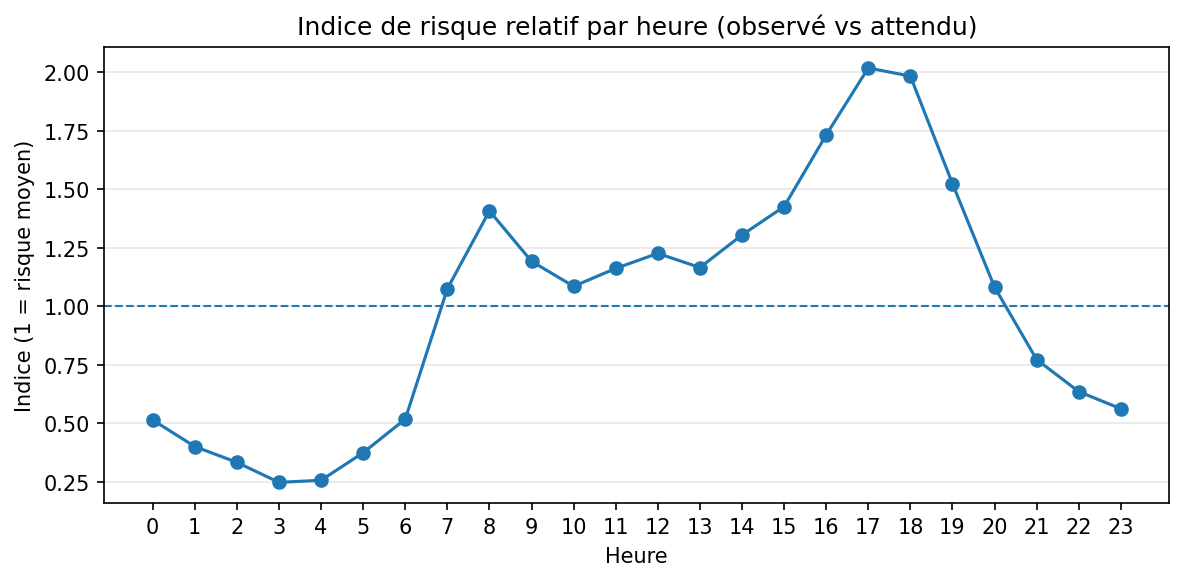

In [4]:
from src.utils import save_fig
import matplotlib.pyplot as plt

acc_per_hour = acc["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)

share_obs = acc_per_hour / acc_per_hour.sum()
share_exp = 1 / 24

risk_index = share_obs / share_exp 

plt.figure(figsize=(8, 4))
plt.plot(risk_index.index, risk_index.values, marker="o", linestyle="-")
plt.axhline(1, linewidth=1, linestyle="--") 

plt.title("Indice de risque relatif par heure (observé vs attendu)")
plt.xlabel("Heure")
plt.ylabel("Indice (1 = risque moyen)")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

path = save_fig("01_risque_relatif_par_heure.png")
display(Image(filename=str(path)))

Ce résultat montre que le risque d’accident n’est pas uniquement lié au trafic, mais aussi à des facteurs comportementaux et contextuels propres à certaines heures (fatigue, conditions de visibilité, usages spécifiques).
L’indice de risque relatif permet ainsi d’identifier des créneaux horaires prioritaires pour les actions de prévention et de contrôle ciblé

## Insight 2 — Répartition hebdomadaire et horaire des accidents

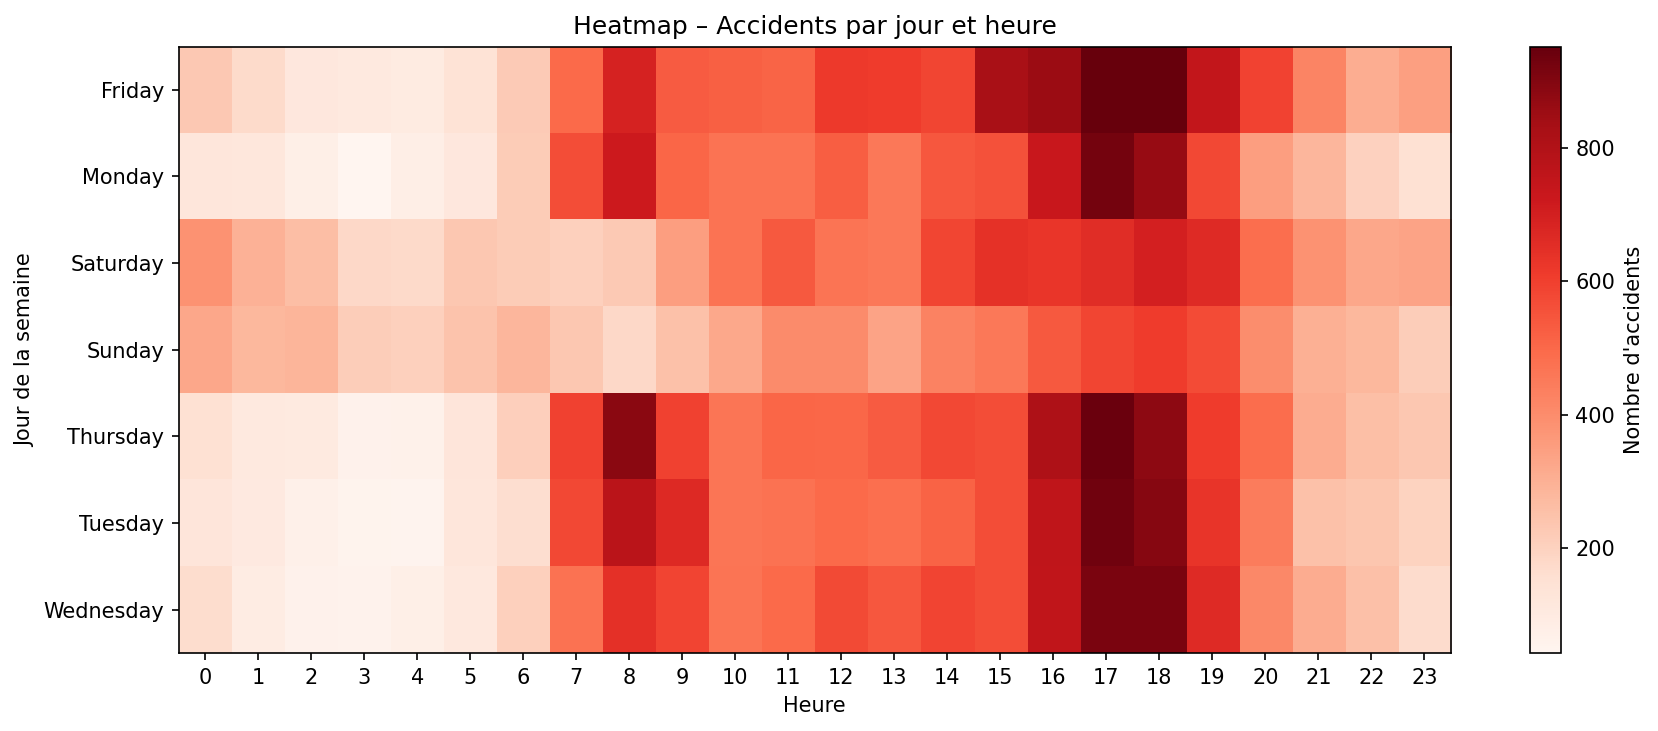

In [5]:
import numpy as np
import matplotlib.pyplot as plt

pivot = (
    acc
    .groupby(["weekday", "hour"])
    .size()
    .unstack(fill_value=0)
)

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
acc_per_day = acc["weekday"].value_counts().reindex(order)

data = pivot.to_numpy()
row_labels = pivot.index.tolist()
col_labels = pivot.columns.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(data, aspect="auto",cmap="Reds")

ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

ax.set_xlabel("Heure")
ax.set_ylabel("Jour de la semaine")
ax.set_title("Heatmap – Accidents par jour et heure")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Nombre d'accidents")

plt.tight_layout()

path = save_fig("02_heatmap_accidents_heure_jour.png")
display(Image(filename=str(path)))


La heatmap jour × heure met en évidence des pics de risque concentrés sur certaines plages horaires. Les accidents se concentrent en semaine aux heures de pointe, avec une nette baisse le dimanche, soulignant le rôle des déplacements domicile-travail.

## Insight 3 — Gravité des accidents impliquant les usagers

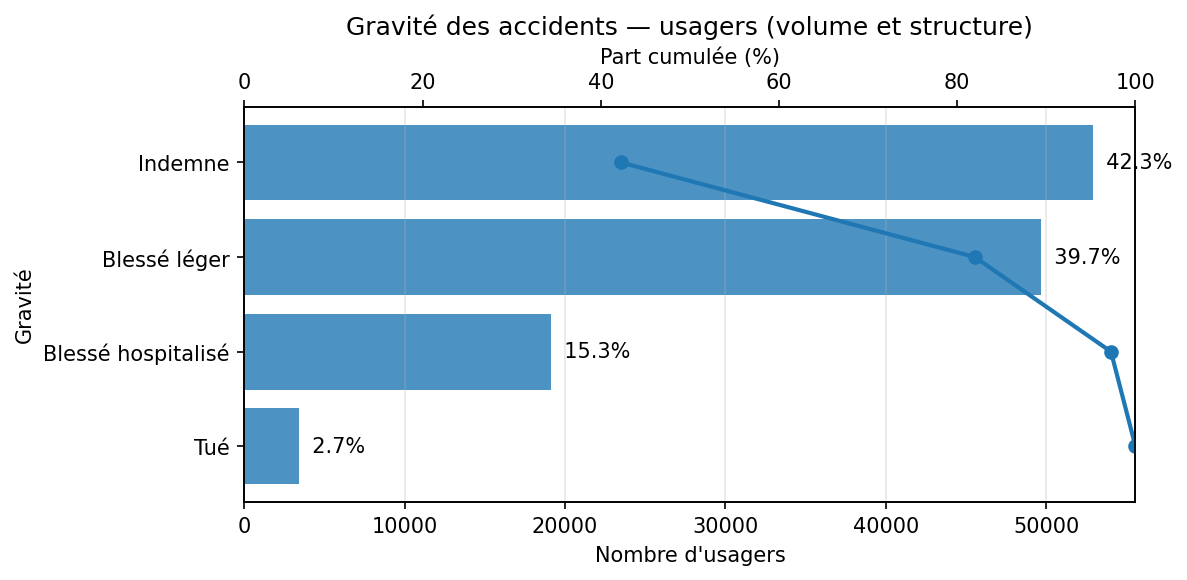

In [6]:
order = ["Indemne", "Blessé léger", "Blessé hospitalisé", "Tué"]

counts = (
    usag["grav_label"]
    .value_counts()
    .reindex(order)
    .fillna(0)
    .astype(int)
)

pct = counts / counts.sum() * 100
cum = pct.cumsum()

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(order, counts.values, alpha=0.8)
ax.invert_yaxis() 

ax.set_title("Gravité des accidents — usagers (volume et structure)")
ax.set_xlabel("Nombre d'usagers")
ax.set_ylabel("Gravité")
ax.grid(axis="x", alpha=0.3)

for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(v, i, f"  {p:.1f}%", va="center")

ax2 = ax.twiny()
ax2.plot(cum.values, range(len(order)), marker="o", linewidth=2)
ax2.set_xlim(0, 100)
ax2.set_xlabel("Part cumulée (%)")

path = save_fig("03_gravite_usagers.png")
display(Image(filename=str(path)))

La majorité des usagers impliqués dans les accidents sont indemnes ou légèrement blessés.
Les accidents mortels restent minoritaires, mais représentent un enjeu majeur en termes de prévention.

## Insight 4 — Périodes horaires à risque élevé

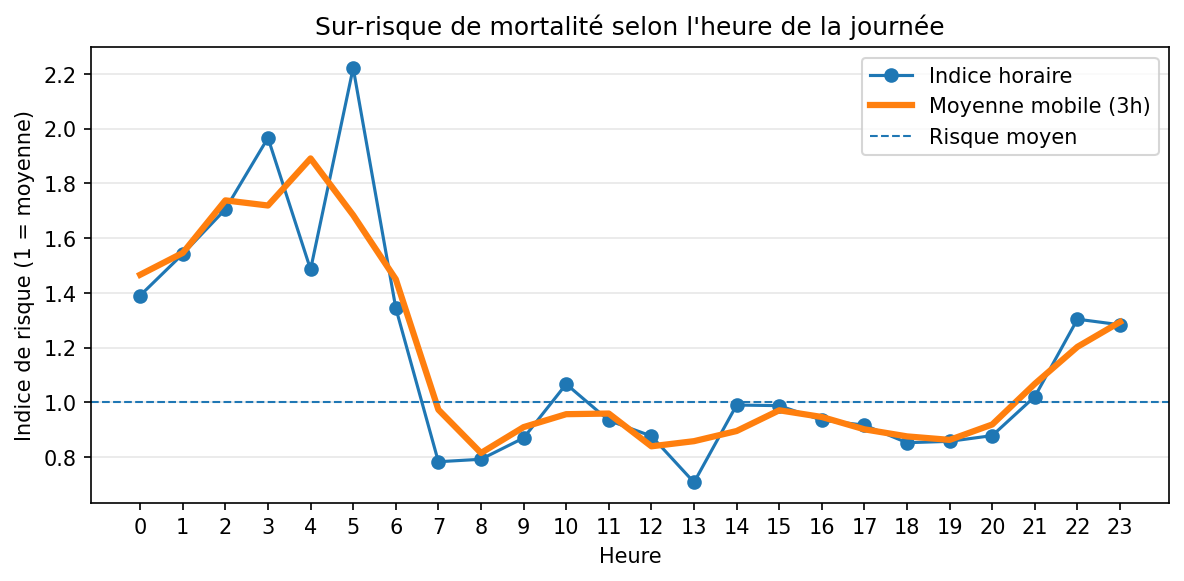

In [7]:
from src.features import merge_usagers_accidents, compute_sur_risque_mortalite_par_heure

usag_acc = merge_usagers_accidents(usag, acc)
usag_acc = compute_sur_risque_mortalite_par_heure(usag_acc, id_col="Num_Acc", hour_col="hour", grav_col="grav_label", fatal_label="Tué", window=3,)

risk_index = usag_acc["risk_index"]
risk_index_ma = usag_acc["risk_index_ma"]

plt.figure(figsize=(8, 4))
plt.plot(risk_index.index, risk_index.values, marker="o", label="Indice horaire")
plt.plot(risk_index_ma.index, risk_index_ma.values, linewidth=3, label="Moyenne mobile (3h)")
plt.axhline(1, linestyle="--", linewidth=1, label="Risque moyen")

plt.title("Sur-risque de mortalité selon l'heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Indice de risque (1 = moyenne)")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.legend()

path = save_fig("04_sur_risque_mortalite_par_heure.png")
display(Image(filename=str(path)))


L’indice de sur-risque révèle une sur-mortalité marquée la nuit et en début de matinée, avec un pic autour de 4–5h.
Ces créneaux présentent une probabilité de décès par accident supérieure à la moyenne, indépendamment du volume d’accidents observé.
À l’inverse, les heures de journée affichent un risque relatif plus faible, suggérant une mortalité principalement liée à l’exposition.

## Insight 5 — Top Départements

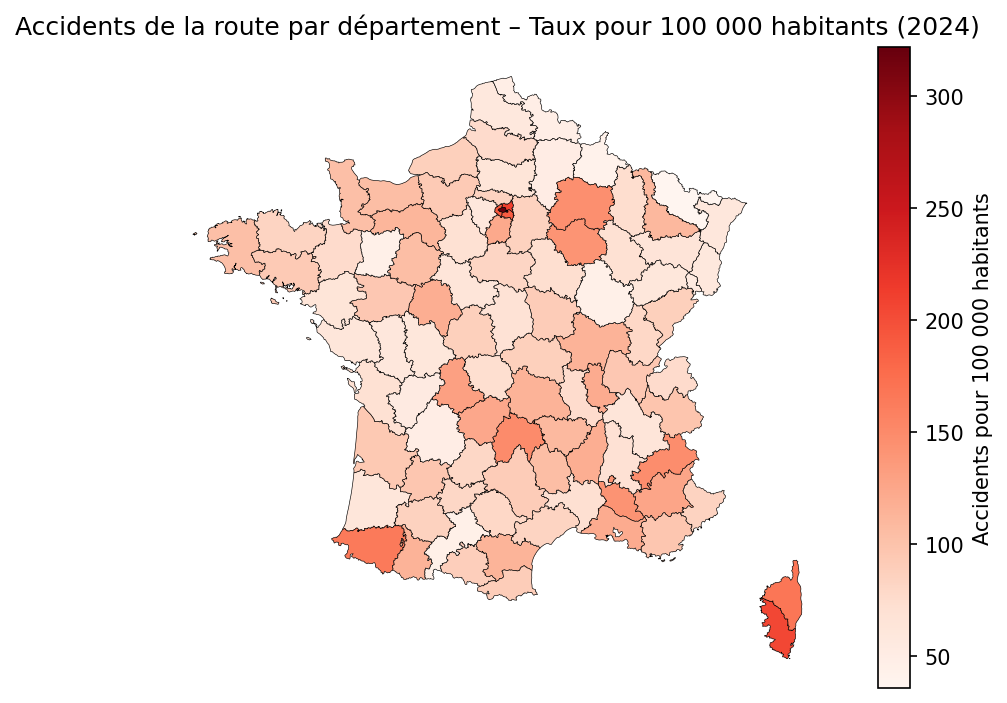

<Figure size 800x1000 with 0 Axes>

In [8]:
import geopandas as gpd
from src.features import accidents_par_departement, merge_accidents_geo, normaliser_dep_metropole, add_taux_100k

pop["dep"] = normaliser_dep_metropole(pop["dep"])
pop = pop.dropna(subset=["dep"])

acc_dep = accidents_par_departement(acc)
acc_dep_norm = add_taux_100k(acc_dep, pop)

geo_path = PROJECT_ROOT / "data" / "geo" / "departements.geojson"
geo_dep = gpd.read_file(geo_path)
geo_dep = geo_dep.rename(columns={"code": "dep"})

geo_dep_acc = merge_accidents_geo(geo_dep, acc_dep_norm)


plt.figure(figsize=(8, 10))

geo_dep_acc.plot(
    column="taux_100k",
    cmap="Reds",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Accidents pour 100 000 habitants"},
    missing_kwds={"color": "lightgrey", "label": "Donnée manquante"},
)

plt.title("Accidents de la route par département – Taux pour 100 000 habitants (2024)")
plt.axis("off")

path = save_fig("05_carte_accidents_par_departement_taux_100k.png")
display(Image(filename=str(path)))

Cette carte présente le taux d’accidents de la route par département en 2024, exprimé pour 100 000 habitants afin de permettre une comparaison équitable entre territoires indépendamment de leur population.

Elle met en évidence des disparités territoriales marquées, révélant des zones proportionnellement plus exposées à l’accidentologie routière et constituant un appui pertinent pour le ciblage des actions de prévention.